# Ablation B: Network vs Non-Network Models

Compares graph neural networks (message passing over an MCN — Molecular Co-occurrence
Network) against non-network baselines, on the same 4-class subset and
the same centralised train/val/test split used across the ablation family



## 1 Imports

In [1]:
import os, csv, time, gc, pickle
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_func
from scipy.sparse import csr_matrix as _csr_mat
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize, StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.utils import dropout_edge
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost: OK')
except ImportError:
    HAS_XGB = False
    print('XGBoost: not available -- skipping')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('All imports OK')


C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost: OK
Device: cuda
All imports OK


## 2 Configuration

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
MGF_PATH          = 'NIST/NIST_GC_EI_MAX_LIBRARY.mgf'
NIST_CLASSES_PATH = 'NIST/nist_classes.csv'
NIST_DIR          = 'C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST'
MASST_TSV_PATH    = f'{NIST_DIR}/results_t50_e20.tsv'
SPLIT_PKL         = os.path.join(RESULTS_DIR, 'split_indices.pkl')
SPLIT_KEY         = 'four_class_v1'   # shared with ablation_a / c / d / e / g

FOUR_CLASSES = [
    'Benzene and substituted derivatives',
    'Carboxylic acids and derivatives',
    'Fatty Acyls',
    'Organooxygen compounds',
]

RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.10

# Every stochastic model is trained on all three of these seeds and reported as
# mean +/- std -- not just the GNNs. Deterministic models (see section 8) are run once.
SEEDS = [42, 123, 2024]

# Classical ML
N_BINS         = 1000
RF_ESTIMATORS  = 300
XGB_ESTIMATORS = 300
XGB_MAX_DEPTH  = 6

# Graph construction (identical to ablation_a / d / e / g)
LEIDEN_SEED     = 42
MIN_LEIDEN_SIZE = 10

# GNN architecture / training
HIDDEN       = 128
NUM_LAYERS   = 2
NUM_HEADS    = 4   # GAT only
DROPOUT      = 0.3
DROP_EDGE_P  = 0.1
CLF_EPOCHS   = 200
CLF_LR       = 1e-3
CLF_PATIENCE = 20
W_SC         = 0.3   # superclass loss weight
W_CL         = 0.7   # class loss weight

ALL_RESULTS = {}   # name -> metrics dict, shared accumulator for every model below

print(f'MASST TSV exists : {os.path.exists(MASST_TSV_PATH)}')
print(f'Seeds             : {SEEDS}')


MASST TSV exists : True
Seeds             : [42, 123, 2024]


## 3 Data Loading (4-class subset)

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for raw in f:
            line = raw.strip()
            if not line: continue
            if line == 'BEGIN IONS':  inside, meta, peaks = True, {}, []; continue
            if line == 'END IONS':
                if inside:
                    entries.append({'meta': meta.copy(),
                        'peaks': np.array(peaks, dtype=float) if peaks
                                 else np.empty((0, 2), dtype=float)})
                inside, meta, peaks = False, {}, []; continue
            if not inside: continue
            if '=' in line: k, v = line.split('=', 1); meta[k.strip()] = v.strip(); continue
            parts = line.split()
            if len(parts) >= 2:
                try: peaks.append([float(parts[0]), float(parts[1])])
                except ValueError: pass
    return entries

def read_nist_classes_csv(path):
    label_map = {}
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for row in csv.DictReader(f):
            sid = int(row['file'].strip())
            sk = row['Superklass'].strip(); k = row['klass'].strip()
            label_map[sid] = {'superclass': None if sk == 'null' else sk,
                              'klass':      None if (k == 'null' or k.startswith('subklass:')) else k}
    return label_map

print('Loading MGF + labels ...')
mgf_entries    = parse_mgf_file(MGF_PATH)
nist_label_map = read_nist_classes_csv(NIST_CLASSES_PATH)

dataset = []
for e in mgf_entries:
    scans = e['meta'].get('SCANS', '').strip()
    if not scans: continue
    try: sid = int(scans)
    except ValueError: continue
    lbl = nist_label_map.get(sid, {'superclass': None, 'klass': None})
    if lbl['superclass'] is None or lbl['klass'] is None: continue
    dataset.append({'scan_id': sid, 'peaks': e['peaks'],
                    'superclass': lbl['superclass'], 'klass': lbl['klass']})

dataset = [r for r in dataset if r['klass'] in FOUR_CLASSES]
print(f'Dataset (4-class subset): {len(dataset):,} spectra')
for cls in FOUR_CLASSES:
    n = sum(1 for r in dataset if r['klass'] == cls)
    print(f'  {n:7,}  {cls}')


Loading MGF + labels ...
Dataset (4-class subset): 84,692 spectra
   42,292  Benzene and substituted derivatives
   17,819  Carboxylic acids and derivatives
   13,925  Fatty Acyls
   10,656  Organooxygen compounds


## 4 Centralised Split

Loaded from `split_indices.pkl` (key `four_class_v1`) if present -- the exact same
70/10/20 stratified split used by `ablation_a`, `ablation_c`, `ablation_d`, `ablation_e`,
and `ablation_g`. Rebuilt and saved under that key otherwise.

In [4]:
node_order_indices = sorted(r['scan_id'] for r in dataset)
scan_to_pos        = {sid: i for i, sid in enumerate(node_order_indices)}
scan_to_ds_idx     = {r['scan_id']: i for i, r in enumerate(dataset)}
N_NODES            = len(node_order_indices)

if os.path.exists(SPLIT_PKL):
    with open(SPLIT_PKL, 'rb') as fh:
        _stored = pickle.load(fh)
    if (isinstance(_stored, dict) and SPLIT_KEY in _stored
            and _stored[SPLIT_KEY]['train_scan_ids'] <= set(node_order_indices)):
        _sp = _stored[SPLIT_KEY]
        train_scan_ids = _sp['train_scan_ids']
        val_scan_ids   = _sp['val_scan_ids']
        test_scan_ids  = _sp['test_scan_ids']
        print(f'Loaded split ({SPLIT_KEY}) from {SPLIT_PKL}')
    else:
        _stored = _stored if isinstance(_stored, dict) else {}
        train_scan_ids = None
        print('Stored split mismatch -- rebuilding ...')
else:
    _stored = {}
    train_scan_ids = None

if train_scan_ids is None:
    all_idx    = list(range(len(dataset)))
    all_labels = [r['klass'] for r in dataset]
    lc         = Counter(all_labels)
    keep       = [i for i in all_idx if lc[all_labels[i]] >= 2]
    kl         = [all_labels[i] for i in keep]
    tr_val, te_idx = train_test_split(keep, test_size=TEST_SIZE,
                                       stratify=kl, random_state=RANDOM_STATE)
    val_rel = VAL_SIZE / (1.0 - TEST_SIZE)
    tr_idx, va_idx = train_test_split(
        tr_val, test_size=val_rel,
        stratify=[all_labels[i] for i in tr_val], random_state=RANDOM_STATE)
    train_scan_ids = {dataset[i]['scan_id'] for i in tr_idx}
    val_scan_ids   = {dataset[i]['scan_id'] for i in va_idx}
    test_scan_ids  = {dataset[i]['scan_id'] for i in te_idx}
    _stored[SPLIT_KEY] = {'train_scan_ids': train_scan_ids,
                          'val_scan_ids':   val_scan_ids,
                          'test_scan_ids':  test_scan_ids}
    with open(SPLIT_PKL, 'wb') as fh:
        pickle.dump(_stored, fh)
    print(f'Created and saved split ({SPLIT_KEY}) to {SPLIT_PKL}')

print(f'Train: {len(train_scan_ids):,}  Val: {len(val_scan_ids):,}  Test: {len(test_scan_ids):,}')


Loaded split (four_class_v1) from results\split_indices.pkl
Train: 59,283  Val: 8,470  Test: 16,939


## 5 Feature Extraction

Two feature representations, shared by every model below:
- **Binned fingerprint** (1000-dim) -- classical ML.
- **Spectral encoding** (340-dim, sinusoidal m/z + intensity) -- MLP and GNN input;
  augmented to 344-dim with 4 MCN community features for the network models (section 10).

In [5]:
def peaks_to_fingerprint(peaks, n_bins=N_BINS, bin_min=0):
    fp = np.zeros(n_bins, dtype=np.float32)
    if peaks is None or len(peaks) == 0: return fp
    p = np.asarray(peaks, dtype=np.float32)
    mz, inty = p[:, 0], p[:, 1]
    max_i = inty.max()
    if max_i <= 0: return fp
    inty = inty / max_i
    bidx = np.floor(mz).astype(int)
    valid = (bidx >= bin_min) & (bidx < bin_min + n_bins)
    np.maximum.at(fp, bidx[valid] - bin_min, inty[valid])
    return fp

def peaks_to_spectral(peaks, top_k=20):
    n_out = top_k * 17
    if peaks is None or len(peaks) == 0: return np.zeros(n_out, dtype=np.float32)
    p = peaks.astype(np.float32)
    p = p[np.argsort(p[:, 1])[::-1][:top_k]]
    if len(p) < top_k:
        p = np.vstack([p, np.zeros((top_k - len(p), 2), dtype=np.float32)])
    mz, inten = p[:, 0], p[:, 1]
    inten = inten / max(inten.max(), 1e-6)
    wl  = np.logspace(-1, 3, num=8, dtype=np.float32)
    ang = (2 * np.pi * mz[:, None]) / wl[None, :]
    enc = np.empty((top_k, 16), dtype=np.float32)
    enc[:, 0::2] = np.sin(ang); enc[:, 1::2] = np.cos(ang)
    return np.concatenate([enc, inten[:, None]], axis=1).flatten()

print('Building binned fingerprints (1000-dim) ...')
x_fp = np.stack([peaks_to_fingerprint(dataset[scan_to_ds_idx[sid]]['peaks'])
                 for sid in node_order_indices], axis=0).astype(np.float32)

print('Building spectral features (340-dim) ...')
raw_x   = np.stack([peaks_to_spectral(dataset[scan_to_ds_idx[sid]]['peaks'])
                    for sid in node_order_indices], axis=0).astype(np.float32)
tr_rows = np.array([scan_to_pos[s] for s in train_scan_ids])
feat_mean = raw_x[tr_rows].mean(0, keepdims=True)
feat_std  = raw_x[tr_rows].std(0,  keepdims=True).clip(min=1e-6)
x_spec    = ((raw_x - feat_mean) / feat_std).astype(np.float32)

print(f'x_fp:   {x_fp.shape}')
print(f'x_spec: {x_spec.shape}')


Building binned fingerprints (1000-dim) ...
Building spectral features (340-dim) ...
x_fp:   (84692, 1000)
x_spec: (84692, 340)


## 6 Labels, Masks, Class Weights

In [6]:
le_sc = LabelEncoder().fit(sorted(set(r['superclass'] for r in dataset)))
le_cl = LabelEncoder().fit(sorted(set(r['klass']      for r in dataset)))
N_SC  = len(le_sc.classes_)
N_CL  = len(le_cl.classes_)

y_sc_np = np.array(
    [int(le_sc.transform([dataset[scan_to_ds_idx[sid]]['superclass']])[0])
     for sid in node_order_indices], dtype=np.int64)
y_cl_np = np.array(
    [int(le_cl.transform([dataset[scan_to_ds_idx[sid]]['klass']])[0])
     for sid in node_order_indices], dtype=np.int64)

y_sc_dev = torch.tensor(y_sc_np, dtype=torch.long).to(DEVICE)
y_cl_dev = torch.tensor(y_cl_np, dtype=torch.long).to(DEVICE)

def make_mask(scan_ids):
    m = np.zeros(N_NODES, dtype=bool)
    for sid in scan_ids:
        if sid in scan_to_pos: m[scan_to_pos[sid]] = True
    return torch.tensor(m, dtype=torch.bool)

train_mask     = make_mask(train_scan_ids)
val_mask       = make_mask(val_scan_ids)
test_mask      = make_mask(test_scan_ids)
train_mask_dev = train_mask.to(DEVICE)
val_mask_dev   = val_mask.to(DEVICE)
test_mask_dev  = test_mask.to(DEVICE)
tr_mask_np     = train_mask.numpy()
va_mask_np     = val_mask.numpy()
te_mask_np     = test_mask.numpy()

sc_to_cl_mask = torch.zeros(N_SC, N_CL, dtype=torch.bool)
for r in dataset:
    sc_to_cl_mask[int(le_sc.transform([r['superclass']])[0]),
                  int(le_cl.transform([r['klass']])[0])] = True
sc_to_cl_mask_dev = sc_to_cl_mask.to(DEVICE)

def make_class_weights(y_np, mask_np, n_classes):
    counts = np.bincount(y_np[mask_np], minlength=n_classes).astype(float)
    w = 1.0 / counts.clip(min=1.0)
    return torch.tensor((w / w.sum() * n_classes).astype(np.float32)).to(DEVICE)

sc_wts = make_class_weights(y_sc_np, tr_mask_np, N_SC)
cl_wts = make_class_weights(y_cl_np, tr_mask_np, N_CL)

# Classical-ML label arrays (le_cl-encoded -- consistent with the GNN's labels)
X_fp_tr, y_tr = x_fp[tr_mask_np], y_cl_np[tr_mask_np]
X_fp_va, y_va = x_fp[va_mask_np], y_cl_np[va_mask_np]
X_fp_te, y_te = x_fp[te_mask_np], y_cl_np[te_mask_np]

print(f'N_SC={N_SC}  N_CL={N_CL}')
print(f'train={train_mask.sum():,}  val={val_mask.sum():,}  test={test_mask.sum():,}')
print(f'Classes: {list(le_cl.classes_)}')


N_SC=4  N_CL=4
train=59,283  val=8,470  test=16,939
Classes: [np.str_('Benzene and substituted derivatives'), np.str_('Carboxylic acids and derivatives'), np.str_('Fatty Acyls'), np.str_('Organooxygen compounds')]


## 7 Graph Homophily Analysis

Before training any GNN: do MASST edges actually connect same-class spectra? If
homophily is near chance level (1/N_CL), message passing has nothing useful to
aggregate and a GNN win over classical ML would be surprising.

Computing graph homophily on training edges ...
  435,619 training MASST edges loaded in 2.5s

  Class homophily: 0.6055  (chance: 0.2500, lift: 2.42x)
  Homophily is MODERATE -- graph may provide modest benefit.


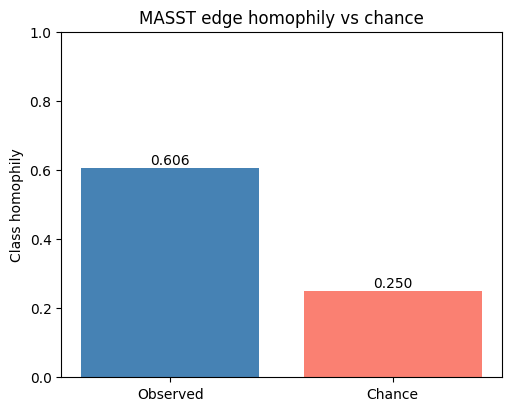

Saved: ablation_b_homophily.png


In [7]:
print('Computing graph homophily on training edges ...')
t0 = time.time()
train_sid_set = set(train_scan_ids)

chunks_h = []
for chunk in pd.read_csv(
        MASST_TSV_PATH, sep='\t',
        usecols=['scan_1', 'scan_2', 'dot_product_shifted'],
        dtype={'scan_1': np.int64, 'scan_2': np.int64, 'dot_product_shifted': np.float32},
        chunksize=500_000):
    chunk = chunk[chunk['scan_1'] != chunk['scan_2']]
    chunk = chunk[chunk['scan_1'].isin(train_sid_set) & chunk['scan_2'].isin(train_sid_set)]
    if len(chunk) > 0:
        chunks_h.append(chunk[['scan_1', 'scan_2', 'dot_product_shifted']])

masst_tr_df = pd.concat(chunks_h, ignore_index=True)
print(f'  {len(masst_tr_df):,} training MASST edges loaded in {time.time()-t0:.1f}s')

sid_to_cl = {r['scan_id']: int(le_cl.transform([r['klass']])[0]) for r in dataset}
masst_tr_df['cl_1'] = masst_tr_df['scan_1'].map(sid_to_cl)
masst_tr_df['cl_2'] = masst_tr_df['scan_2'].map(sid_to_cl)
masst_tr_df = masst_tr_df.dropna(subset=['cl_1', 'cl_2'])

h_cl    = (masst_tr_df['cl_1'] == masst_tr_df['cl_2']).mean()
chance  = 1.0 / N_CL
print(f'\n  Class homophily: {h_cl:.4f}  (chance: {chance:.4f}, lift: {h_cl/chance:.2f}x)')
if h_cl < 0.40:
    print('  Homophily is LOW -- most edges cross class boundaries.')
elif h_cl < 0.70:
    print('  Homophily is MODERATE -- graph may provide modest benefit.')
else:
    print('  Homophily is HIGH -- graph should strongly benefit classification.')

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.bar(['Observed', 'Chance'], [h_cl, chance], color=['steelblue', 'salmon'])
for i, v in enumerate([h_cl, chance]):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
ax.set_ylim(0, 1); ax.set_ylabel('Class homophily'); ax.set_title('MASST edge homophily vs chance')
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_b_homophily.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_b_homophily.png')


## 8 Non-Network Baselines

Every stochastic model is run on all 3 `SEEDS` and reported as mean ± std.
Deterministic models are run once and explicitly labelled:

- **Majority class** and **Cosine NN** have no randomness at all.
- **SVM (RBF)** is also deterministic here: `SVC`'s `random_state` only affects the
  internal probability-calibration routine, which we don't use (`probability=False`
  by default), so `random_state` has no effect on `.fit()`/`.predict()`.

In [8]:
def record_classical(name, accs, f1s, per_class_f1s, tr_times, inf_times, n_seeds,
                     y_true_example, y_pred_example):
    ALL_RESULTS[name] = {
        'accuracy_mean': round(float(np.mean(accs)), 4),
        'accuracy_std':  round(float(np.std(accs)), 4),
        'macro_f1_mean': round(float(np.mean(f1s)), 4),
        'macro_f1_std':  round(float(np.std(f1s)), 4),
        'macro_f1_all':  [round(float(v), 4) for v in f1s],
        'per_class_f1':  np.mean(per_class_f1s, axis=0),
        'train_s':       round(float(np.mean(tr_times)), 1),
        'infer_ms':      round(float(np.mean(inf_times)) * 1000 / max(len(y_true_example), 1), 3),
        'n_seeds':       n_seeds,
        'y_true_example': y_true_example,
        'y_pred_example': y_pred_example,
    }
    r = ALL_RESULTS[name]
    tag = f'{n_seeds} seed' + ('s' if n_seeds > 1 else '') if n_seeds > 1 else 'deterministic'
    print(f'  {name}: acc={r["accuracy_mean"]:.4f}+/-{r["accuracy_std"]:.4f}  '
          f'macro-F1={r["macro_f1_mean"]:.4f}+/-{r["macro_f1_std"]:.4f}  ({tag})')

def run_classical(name, model_factory, seeds, deterministic=False):
    use_seeds = [seeds[0]] if deterministic else seeds
    accs, f1s, pcs, tr_times, inf_times = [], [], [], [], []
    y_pred_example = None
    for sd in use_seeds:
        model = model_factory(sd)
        t0 = time.time(); model.fit(X_fp_tr, y_tr); tr_t = time.time() - t0
        t0 = time.time(); pred = model.predict(X_fp_te); inf_t = time.time() - t0
        accs.append(accuracy_score(y_te, pred))
        f1s.append(f1_score(y_te, pred, average='macro', zero_division=0))
        pcs.append(f1_score(y_te, pred, average=None, zero_division=0, labels=np.arange(N_CL)))
        tr_times.append(tr_t); inf_times.append(inf_t)
        if y_pred_example is None: y_pred_example = pred
    record_classical(name, accs, f1s, pcs, tr_times, inf_times, len(use_seeds), y_te, y_pred_example)

# --- Floor: Majority class ---
print('Majority Class (floor) ...')
run_classical('Majority Class', lambda sd: DummyClassifier(strategy='most_frequent'),
               SEEDS, deterministic=True)

# --- Domain baseline: Cosine Similarity 1-NN ---
print('Cosine Similarity NN ...')
class CosineNN:
    def fit(self, X, y):
        self.Xn = normalize(X, norm='l2'); self.y = y
        self.nn = NearestNeighbors(n_neighbors=1, metric='cosine', algorithm='brute', n_jobs=-1)
        self.nn.fit(self.Xn); return self
    def predict(self, X):
        _, idx = self.nn.kneighbors(normalize(X, norm='l2'))
        return self.y[idx.ravel()]
run_classical('Cosine NN', lambda sd: CosineNN(), SEEDS, deterministic=True)


Majority Class (floor) ...
  Majority Class: acc=0.4994+/-0.0000  macro-F1=0.1665+/-0.0000  (deterministic)
Cosine Similarity NN ...
  Cosine NN: acc=0.7866+/-0.0000  macro-F1=0.7414+/-0.0000  (deterministic)


In [9]:
# --- Logistic Regression ---
print('Logistic Regression ...')
run_classical('Logistic Regression',
    lambda sd: LogisticRegression(max_iter=2000, class_weight='balanced',
                                   random_state=sd, n_jobs=-1),
    SEEDS, deterministic=False)

# --- Random Forest ---
print('Random Forest ...')
run_classical('Random Forest',
    lambda sd: RandomForestClassifier(n_estimators=RF_ESTIMATORS, max_features='sqrt',
                                       class_weight='balanced', random_state=sd, n_jobs=-1),
    SEEDS, deterministic=False)

# --- SVM (RBF) -- deterministic: random_state only affects probability calibration,
#     which we don't use (probability=False by default) ---
print('SVM (RBF) ...')
run_classical('SVM (RBF)',
    lambda sd: Pipeline([('scaler', StandardScaler()),
                         ('svm', SVC(kernel='rbf', C=10.0, gamma='scale',
                                     class_weight='balanced', random_state=sd))]),
    SEEDS, deterministic=True)

# --- XGBoost ---
if HAS_XGB:
    print('XGBoost ...')
    def _xgb_factory(sd):
        return xgb.XGBClassifier(n_estimators=XGB_ESTIMATORS, max_depth=XGB_MAX_DEPTH,
                                  learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                                  eval_metric='mlogloss', random_state=sd, n_jobs=-1,
                                  tree_method='hist')
    run_classical('XGBoost', _xgb_factory, SEEDS, deterministic=False)
else:
    print('XGBoost not available -- skipping')

print('\nNon-network baselines done.')


Logistic Regression ...
  Logistic Regression: acc=0.6741+/-0.0000  macro-F1=0.6237+/-0.0000  (3 seeds)
Random Forest ...
  Random Forest: acc=0.8250+/-0.0004  macro-F1=0.7646+/-0.0008  (3 seeds)
SVM (RBF) ...
  SVM (RBF): acc=0.7926+/-0.0000  macro-F1=0.7512+/-0.0000  (deterministic)
XGBoost ...
  XGBoost: acc=0.8472+/-0.0007  macro-F1=0.7985+/-0.0011  (3 seeds)

Non-network baselines done.


## 9 MLP Baseline (no graph, multi-seed)

In [10]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, n_cls, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_cls))
    def forward(self, x): return self.net(x)

def run_mlp_multiseed(seeds):
    X_tr_t = torch.tensor(x_spec[tr_mask_np], dtype=torch.float32).to(DEVICE)
    X_va_t = torch.tensor(x_spec[va_mask_np], dtype=torch.float32).to(DEVICE)
    X_te_t = torch.tensor(x_spec[te_mask_np], dtype=torch.float32).to(DEVICE)
    y_tr_t = torch.tensor(y_cl_np[tr_mask_np], dtype=torch.long).to(DEVICE)
    y_va_t = torch.tensor(y_cl_np[va_mask_np], dtype=torch.long).to(DEVICE)

    accs, f1s, pcs, tr_times, inf_times = [], [], [], [], []
    y_pred_example = None
    for sd in seeds:
        torch.manual_seed(sd)
        model = MLP(340, 256, N_CL, DROPOUT).to(DEVICE)
        opt   = torch.optim.AdamW(model.parameters(), lr=CLF_LR, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5,
                                                             patience=10, min_lr=1e-6)
        crit  = nn.CrossEntropyLoss(weight=cl_wts)
        best_val_f1 = 0.0; best_state = None; es_ctr = 0
        t0 = time.time()
        for epoch in range(1, CLF_EPOCHS + 1):
            model.train(); opt.zero_grad()
            loss = crit(model(X_tr_t), y_tr_t)
            loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                val_f1 = f1_score(y_va_t.cpu(), model(X_va_t).argmax(1).cpu(),
                                  average='macro', zero_division=0)
            sched.step(val_f1)
            if val_f1 > best_val_f1 + 1e-4:
                best_val_f1 = val_f1; es_ctr = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                es_ctr += 1
            if es_ctr >= CLF_PATIENCE: break
        tr_t = time.time() - t0
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()}); model.eval()
        t0 = time.time()
        with torch.no_grad(): pred = model(X_te_t).argmax(1).cpu().numpy()
        inf_t = time.time() - t0

        accs.append(accuracy_score(y_te, pred))
        f1s.append(f1_score(y_te, pred, average='macro', zero_division=0))
        pcs.append(f1_score(y_te, pred, average=None, zero_division=0, labels=np.arange(N_CL)))
        tr_times.append(tr_t); inf_times.append(inf_t)
        if y_pred_example is None: y_pred_example = pred
        del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    record_classical('MLP (no graph)', accs, f1s, pcs, tr_times, inf_times, len(seeds),
                     y_te, y_pred_example)

print('MLP (no graph, multi-seed) ...')
run_mlp_multiseed(SEEDS)


MLP (no graph, multi-seed) ...
  MLP (no graph): acc=0.6026+/-0.0013  macro-F1=0.5418+/-0.0016  (3 seeds)


## 10 Transductive Molecular Network + MCN 

In [11]:
def build_transductive_mcn(masst_tsv_path, scan_to_pos, x_spec, node_order_indices, n_nodes,
                            min_leiden_size=10, leiden_seed=42):
    all_scan_ids = set(scan_to_pos)

    pairs = []
    for chunk in pd.read_csv(
            masst_tsv_path, sep='\t',
            usecols=['scan_1', 'scan_2', 'dot_product_shifted'],
            dtype={'scan_1': np.int64, 'scan_2': np.int64, 'dot_product_shifted': np.float32},
            chunksize=500_000):
        chunk = chunk[chunk['scan_1'] != chunk['scan_2']]
        chunk = chunk[chunk['scan_1'].isin(all_scan_ids) & chunk['scan_2'].isin(all_scan_ids)]
        if len(chunk) == 0:
            continue
        u = chunk['scan_1'].map(scan_to_pos).to_numpy()
        v = chunk['scan_2'].map(scan_to_pos).to_numpy()
        pairs.append(np.column_stack([np.minimum(u, v), np.maximum(u, v),
                                      chunk['dot_product_shifted'].to_numpy()]))

    allp = np.concatenate(pairs, axis=0) if pairs else np.zeros((0, 3), dtype=np.float32)
    edf  = pd.DataFrame({'u': allp[:, 0].astype(np.int64),
                         'v': allp[:, 1].astype(np.int64),
                         'cosine_score': allp[:, 2].astype(np.float32)})
    edf  = edf.groupby(['u', 'v'], as_index=False)['cosine_score'].max()

    G = nx.from_pandas_edgelist(edf, 'u', 'v', edge_attr='cosine_score')
    G.add_nodes_from(range(n_nodes))

    all_components = sorted(nx.connected_components(G), key=len, reverse=True)
    mcn_pos_to_comm = {}
    next_comm_id    = 0
    for comp_nodes in all_components:
        size = len(comp_nodes)
        if size == 1:
            node = list(comp_nodes)[0]
            mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        elif size < min_leiden_size:
            for node in comp_nodes:
                mcn_pos_to_comm[node] = next_comm_id
            next_comm_id += 1
        else:
            comp_nodes_sorted = sorted(comp_nodes)
            local_remap       = {old: new for new, old in enumerate(comp_nodes_sorted)}
            subgraph          = G.subgraph(comp_nodes_sorted)

            ig_comp = ig.Graph(n=size, directed=False)
            ig_comp.add_edges([(local_remap[u], local_remap[v]) for u, v in subgraph.edges()])
            ig_comp.es['weight'] = [subgraph.edges[u, v]['cosine_score'] for u, v in subgraph.edges()]

            part = leidenalg.find_partition(
                ig_comp, leidenalg.ModularityVertexPartition,
                weights='weight', seed=leiden_seed)

            for local_i, mcn_pos in enumerate(comp_nodes_sorted):
                mcn_pos_to_comm[mcn_pos] = next_comm_id + int(part.membership[local_i])
            next_comm_id += len(part)
    n_communities = next_comm_id
    singleton_nodes = {node for node in G.nodes() if G.degree(node) == 0}

    comm_to_nodes = defaultdict(list)
    for mcn_pos, comm_id in mcn_pos_to_comm.items():
        comm_to_nodes[comm_id].append(mcn_pos)

    mst_edges = []
    for cid in range(n_communities):
        members = comm_to_nodes[cid]
        if len(members) <= 1:
            continue
        local_idx       = {mcn_pos: i for i, mcn_pos in enumerate(members)}
        n_c             = len(members)
        rows, cols, wts = [], [], []
        for u in members:
            for v in G.neighbors(u):
                if mcn_pos_to_comm.get(v) == cid and v in local_idx:
                    rows.append(local_idx[u])
                    cols.append(local_idx[v])
                    wts.append(G.edges[u, v]['cosine_score'])
        if not rows:
            continue
        mat = _csr_mat((np.array(wts, dtype=np.float32), (rows, cols)), shape=(n_c, n_c))
        neg = mat.copy(); neg.data *= -1
        mst = _mst_func(neg).tocoo(); mst.data *= -1
        for r, c, w in zip(mst.row, mst.col, mst.data):
            mst_edges.append((members[r], members[c], float(w)))

    if mst_edges:
        src_list = [u for u, v, w in mst_edges]
        dst_list = [v for u, v, w in mst_edges]
        wts_list = [w for u, v, w in mst_edges]
        src_bi = src_list + dst_list
        dst_bi = dst_list + src_list
        wts_bi = wts_list + wts_list
        mcn_edge_index = torch.tensor([src_bi, dst_bi], dtype=torch.long)
        mcn_edge_attr  = torch.tensor(wts_bi, dtype=torch.float32).unsqueeze(1)
    else:
        mcn_edge_index = torch.zeros((2, 0), dtype=torch.long)
        mcn_edge_attr  = torch.zeros((0, 1), dtype=torch.float32)

    node_comm_id   = np.array([mcn_pos_to_comm[i] for i in range(n_nodes)], dtype=np.int64)
    comm_sizes_arr = np.bincount(node_comm_id, minlength=n_communities)

    comm_centroids = np.zeros((n_communities, x_spec.shape[1]), dtype=np.float32)
    np.add.at(comm_centroids, node_comm_id, x_spec)
    comm_centroids /= np.maximum(comm_sizes_arr[:, None], 1)

    f_log_size = np.log1p(comm_sizes_arr[node_comm_id]).astype(np.float32)

    degree_arr    = np.array([G.degree(i) for i in range(n_nodes)], dtype=np.float32)
    size_m1       = np.maximum(comm_sizes_arr[node_comm_id] - 1, 1).astype(np.float32)
    f_degree_cent = (degree_arr / size_m1).clip(0, 1)

    diffs       = x_spec - comm_centroids[node_comm_id]
    f_dist_cent = np.linalg.norm(diffs, axis=1).astype(np.float32)

    f_singleton = np.array([1.0 if i in singleton_nodes else 0.0 for i in range(n_nodes)],
                           dtype=np.float32)

    comm_features = np.stack([f_log_size, f_degree_cent, f_dist_cent, f_singleton], axis=1).astype(np.float32)
    x_aug = np.concatenate([x_spec, comm_features], axis=1).astype(np.float32)

    sid_to_klass = {r['scan_id']: r['klass'] for r in dataset}
    comm_members = defaultdict(list)
    for pos in range(n_nodes):
        comm_members[node_comm_id[pos]].append(pos)
    purities = []
    for cid in range(n_communities):
        klasses = [sid_to_klass[node_order_indices[p]]
                   for p in comm_members.get(cid, [])
                   if node_order_indices[p] in sid_to_klass]
        if not klasses:
            continue
        dominant_n = Counter(klasses).most_common(1)[0][1]
        purities.append(dominant_n / len(klasses))
    mean_purity = float(np.mean(purities)) if purities else float('nan')

    info = {
        'n_edges':       G.number_of_edges(),
        'n_communities': n_communities,
        'n_mst_edges':   len(mst_edges),
        'n_singletons':  len(singleton_nodes),
        'mean_purity':   mean_purity,
    }

    x_aug_dev      = torch.tensor(x_aug, dtype=torch.float32).to(DEVICE)
    mcn_edge_index = mcn_edge_index.to(DEVICE)
    mcn_edge_attr  = mcn_edge_attr.to(DEVICE)

    return x_aug_dev, mcn_edge_index, mcn_edge_attr, info


print('Building transductive molecular network + MCN (ablation_a pipeline) ...')
x_aug_dev, mcn_ei_dev, mcn_ea_dev, mcn_info = build_transductive_mcn(
    MASST_TSV_PATH, scan_to_pos, x_spec, node_order_indices, N_NODES,
    min_leiden_size=MIN_LEIDEN_SIZE, leiden_seed=LEIDEN_SEED,
)

# same graph used for training AND eval (transductive); loss stays masked to train_mask
ei_tr_d, ea_tr_d = mcn_ei_dev, mcn_ea_dev
ei_ev_d, ea_ev_d = mcn_ei_dev, mcn_ea_dev

print(f'MCN : {mcn_info["n_edges"]:,} MASST edges  {mcn_info["n_communities"]:,} communities  '
      f'{mcn_info["n_mst_edges"]:,} MWST edges  {mcn_info["n_singletons"]:,} singletons  '
      f'mean_purity={mcn_info["mean_purity"]:.3f}')
print(f'x_aug_dev={x_aug_dev.shape}  edges={mcn_ei_dev.shape[1]:,}')


Building transductive molecular network + MCN (ablation_a pipeline) ...
MCN : 888,192 MASST edges  9,087 communities  75,600 MWST edges  357 singletons  mean_purity=0.954
x_aug_dev=torch.Size([84692, 344])  edges=151,200


## 11 Network Models: GAT + MCN and GCN + MCN

Two independently-trained architectures on the **same** transductive MCN graph and
features. If both beat the non-network baselines, the "graph helps" claim rests on
more than a single model's idiosyncrasies. Both share the hierarchical dual-head
wrapper; only the conv layer differs (`GATConv` with cosine edge attention vs
`GCNConv` with cosine edge weights, no attention).

In [12]:
class GATBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=DROPOUT, dep=DROP_EDGE_P, heads=NUM_HEADS):
        super().__init__()
        assert out_ch % heads == 0; self.dep = dep
        self.conv = GATConv(in_ch, out_ch // heads, heads=heads, concat=True,
                            dropout=dropout, edge_dim=1, add_self_loops=False)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0 and ei.shape[1] > 0:
            ei, mask = dropout_edge(ei, p=self.dep, force_undirected=True, training=True)
            ea = ea[mask]
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_attr=ea))) + self.res(x))

class GCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=DROPOUT, dep=DROP_EDGE_P, heads=NUM_HEADS):
        super().__init__()
        self.dep = dep
        self.conv = GCNConv(in_ch, out_ch, add_self_loops=True)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0 and ei.shape[1] > 0:
            ei, mask = dropout_edge(ei, p=self.dep, force_undirected=True, training=True)
            ea = ea[mask]
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_weight=ea.squeeze(-1)))) + self.res(x))


class HierarchicalGNN(nn.Module):
    def __init__(self, feat_dim, block_cls, hidden=HIDDEN, num_layers=NUM_LAYERS,
                 n_sc=N_SC, n_cl=N_CL, dropout=DROPOUT, drop_edge_p=DROP_EDGE_P, heads=NUM_HEADS):
        super().__init__()
        self.norm_in = nn.LayerNorm(feat_dim)
        self.proj    = nn.Sequential(nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden),
                                     nn.GELU(), nn.Dropout(dropout))
        self.layers  = nn.ModuleList([block_cls(hidden, hidden, dropout, drop_edge_p, heads)
                                      for _ in range(num_layers)])
        self.jk      = nn.Sequential(nn.Linear(hidden * (num_layers + 1), hidden),
                                     nn.LayerNorm(hidden), nn.GELU())
        self.sc_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(hidden // 2, n_sc))
        self.cl_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(hidden // 2, n_cl))

    def encode(self, x, ei, ea, training=False):
        h = self.proj(self.norm_in(x)); hs = [h]
        for layer in self.layers:
            h = layer(h, ei, ea, training); hs.append(h)
        return self.jk(torch.cat(hs, dim=-1))

    def forward(self, x, ei, ea, training=False):
        emb = self.encode(x, ei, ea, training)
        return self.sc_head(emb), self.cl_head(emb)

    def predict(self, x, ei, ea, sc_cl_mask):
        self.eval()
        with torch.no_grad():
            sc_lg, cl_lg = self.forward(x, ei, ea)
            cl_lg = cl_lg.masked_fill(~sc_cl_mask[sc_lg.argmax(1)], float('-inf'))
        return sc_lg, cl_lg


def train_gnn_one_seed(block_cls, seed):
    torch.manual_seed(seed)
    model = HierarchicalGNN(x_aug_dev.shape[1], block_cls).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=CLF_LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5,
                                                         patience=10, min_lr=1e-6)
    crit_sc = nn.CrossEntropyLoss(weight=sc_wts)
    crit_cl = nn.CrossEntropyLoss(weight=cl_wts)

    best_val_f1 = 0.0; best_state = None; es_ctr = 0
    t0 = time.time()
    for epoch in range(1, CLF_EPOCHS + 1):
        model.train(); opt.zero_grad()
        sc_lg, cl_lg = model(x_aug_dev, ei_tr_d, ea_tr_d, training=True)
        loss = (W_SC * crit_sc(sc_lg[train_mask_dev], y_sc_dev[train_mask_dev])
              + W_CL * crit_cl(cl_lg[train_mask_dev], y_cl_dev[train_mask_dev]))
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            sc_lg_v, cl_lgm = model.predict(x_aug_dev, ei_ev_d, ea_ev_d, sc_to_cl_mask_dev)
            val_f1 = f1_score(y_cl_dev[val_mask_dev].cpu(), cl_lgm[val_mask_dev].argmax(1).cpu(),
                              average='macro', zero_division=0)
        sched.step(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1; es_ctr = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            es_ctr += 1
        if es_ctr >= CLF_PATIENCE: break
    tr_t = time.time() - t0

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()}); model.eval()
    t0 = time.time()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(x_aug_dev, ei_ev_d, ea_ev_d, sc_to_cl_mask_dev)
    inf_t = time.time() - t0

    pred = cl_lgm[test_mask_dev].argmax(1).cpu().numpy()
    true = y_cl_dev[test_mask_dev].cpu().numpy()
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return true, pred, tr_t, inf_t


def run_gnn_multiseed(name, block_cls, seeds):
    accs, f1s, pcs, tr_times, inf_times = [], [], [], [], []
    y_pred_example = None; y_true_example = None
    for sd in seeds:
        true, pred, tr_t, inf_t = train_gnn_one_seed(block_cls, sd)
        accs.append(accuracy_score(true, pred))
        f1s.append(f1_score(true, pred, average='macro', zero_division=0))
        pcs.append(f1_score(true, pred, average=None, zero_division=0, labels=np.arange(N_CL)))
        tr_times.append(tr_t); inf_times.append(inf_t)
        if y_pred_example is None: y_pred_example, y_true_example = pred, true
        print(f'  [{name}] seed={sd:<5d} Test acc={accs[-1]:.4f}  Test macro-F1={f1s[-1]:.4f}')
    record_classical(name, accs, f1s, pcs, tr_times, inf_times, len(seeds),
                     y_true_example, y_pred_example)

print('Training GAT + MCN (3 seeds) ...')
run_gnn_multiseed('GAT + MCN (ours)', GATBlock, SEEDS)

print('\nTraining GCN + MCN (3 seeds) ...')
run_gnn_multiseed('GCN + MCN', GCNBlock, SEEDS)


Training GAT + MCN (3 seeds) ...
  [GAT + MCN (ours)] seed=42    Test acc=0.6131  Test macro-F1=0.5504
  [GAT + MCN (ours)] seed=123   Test acc=0.6176  Test macro-F1=0.5569
  [GAT + MCN (ours)] seed=2024  Test acc=0.6162  Test macro-F1=0.5531
  GAT + MCN (ours): acc=0.6156+/-0.0019  macro-F1=0.5535+/-0.0027  (3 seeds)

Training GCN + MCN (3 seeds) ...
  [GCN + MCN] seed=42    Test acc=0.6196  Test macro-F1=0.5582
  [GCN + MCN] seed=123   Test acc=0.6118  Test macro-F1=0.5549
  [GCN + MCN] seed=2024  Test acc=0.6128  Test macro-F1=0.5558
  GCN + MCN: acc=0.6148+/-0.0035  macro-F1=0.5563+/-0.0014  (3 seeds)


## 12 Comprehensive Results Table

In [13]:
CATEGORY = {
    'Majority Class':      'Floor',
    'Cosine NN':           'Domain baseline',
    'Logistic Regression': 'Classical ML',
    'Random Forest':       'Classical ML',
    'SVM (RBF)':           'Classical ML',
    'XGBoost':              'Classical ML',
    'MLP (no graph)':      'Deep learning (no graph)',
    'GAT + MCN (ours)':    'Graph neural network',
    'GCN + MCN':           'Graph neural network',
}

rows = []
for name, m in ALL_RESULTS.items():
    rows.append({
        'Model': name,
        'Category': CATEGORY.get(name, 'Other'),
        'Accuracy':   f'{m["accuracy_mean"]:.4f} +/- {m["accuracy_std"]:.4f}',
        'Macro-F1':   f'{m["macro_f1_mean"]:.4f} +/- {m["macro_f1_std"]:.4f}',
        'N seeds':    m['n_seeds'],
        'Train (s)':  m['train_s'],
        'Infer (ms/sample)': m['infer_ms'],
        '_sort': m['macro_f1_mean'],
    })
df_results = (pd.DataFrame(rows).sort_values('_sort', ascending=False)
              .drop(columns='_sort').reset_index(drop=True))
print('\n' + '='*90)
print('  ALL MODELS -- Test Set Results (mean +/- std over N seeds)')
print('='*90)
print(df_results.to_string(index=False))
df_results.to_csv(os.path.join(RESULTS_DIR, 'ablation_b_results.csv'), index=False)
print('\nSaved: ablation_b_results.csv')



  ALL MODELS -- Test Set Results (mean +/- std over N seeds)
              Model                 Category          Accuracy          Macro-F1  N seeds  Train (s)  Infer (ms/sample)
            XGBoost             Classical ML 0.8472 +/- 0.0007 0.7985 +/- 0.0011        3       82.5              0.006
      Random Forest             Classical ML 0.8250 +/- 0.0004 0.7646 +/- 0.0008        3       17.8              0.022
          SVM (RBF)             Classical ML 0.7926 +/- 0.0000 0.7512 +/- 0.0000        1     5065.5             40.384
          Cosine NN          Domain baseline 0.7866 +/- 0.0000 0.7414 +/- 0.0000        1        0.3              0.970
Logistic Regression             Classical ML 0.6741 +/- 0.0000 0.6237 +/- 0.0000        3       10.0              0.003
          GCN + MCN     Graph neural network 0.6148 +/- 0.0035 0.5563 +/- 0.0014        3       10.4              0.001
   GAT + MCN (ours)     Graph neural network 0.6156 +/- 0.0019 0.5535 +/- 0.0027        3       12

## 13 Statistical Comparison: Network vs Non-Network

Two checks on the best network model vs the best non-network model:
1. **Heuristic** (same as `ablation_c`): is the gap in mean macro-F1 larger than the
   combined std of the two models? A rough signal, not a formal test.
2. **Welch's t-test** on the 3 per-seed macro-F1 values of each model. With n=3 per
   group this test has very low power -- a non-significant p-value here does **not**
   mean "no difference", only that 3 seeds can't resolve it. Treat both checks as
   suggestive, not conclusive; a real paper would want more seeds.

In [14]:
network_names     = ['GAT + MCN (ours)', 'GCN + MCN']
non_network_names = [n for n in ALL_RESULTS if n not in network_names]

best_network     = max(network_names, key=lambda n: ALL_RESULTS[n]['macro_f1_mean'])
best_non_network = max(non_network_names, key=lambda n: ALL_RESULTS[n]['macro_f1_mean'])

mn, sn = ALL_RESULTS[best_network]['macro_f1_mean'], ALL_RESULTS[best_network]['macro_f1_std']
mb, sb = ALL_RESULTS[best_non_network]['macro_f1_mean'], ALL_RESULTS[best_non_network]['macro_f1_std']
diff   = mn - mb
noise  = sn + sb
verdict = 'likely real' if abs(diff) > noise else 'within seed noise'

print(f'Best network model     : {best_network:<22} {mn:.4f} +/- {sn:.4f}')
print(f'Best non-network model : {best_non_network:<22} {mb:.4f} +/- {sb:.4f}')
print(f'Diff (network - non-network): {diff:+.4f}   combined std: {noise:.4f}   -> {verdict}')

na = np.array(ALL_RESULTS[best_network]['macro_f1_all'])
nb_ = np.array(ALL_RESULTS[best_non_network]['macro_f1_all'])
if len(na) >= 2 and len(nb_) >= 2:
    t_stat, p_val = stats.ttest_ind(na, nb_, equal_var=False)
    print(f"\nWelch's t-test on per-seed macro-F1: t={t_stat:.3f}  p={p_val:.4f}")
    print('  (n=3 per group -- low power; interpret cautiously)')
else:
    print("\nWelch's t-test skipped: one of the two models is deterministic (n_seeds<2).")

print(f'\nClass homophily (context): {h_cl:.4f}  (chance: {chance:.4f})')
if diff > 0:
    print('=> Graph structure DOES improve over the best non-network model on this dataset.')
else:
    print('=> Graph structure does NOT improve over the best non-network model on this dataset.')


Best network model     : GCN + MCN              0.5563 +/- 0.0014
Best non-network model : XGBoost                0.7985 +/- 0.0011
Diff (network - non-network): -0.2422   combined std: 0.0025   -> likely real

Welch's t-test on per-seed macro-F1: t=-193.092  p=0.0000
  (n=3 per group -- low power; interpret cautiously)

Class homophily (context): 0.6055  (chance: 0.2500)
=> Graph structure does NOT improve over the best non-network model on this dataset.


## 14 Per-Class F1 Breakdown

Per-class F1 (mean over seeds; hardest classes at top):
Model                                Cosine NN  GAT + MCN (ours)  GCN + MCN  Logistic Regression  MLP (no graph)  Majority Class  Random Forest  SVM (RBF)  XGBoost
Class                                                                                                                                                              
Organooxygen compounds                  0.5828            0.3763     0.3823               0.4189          0.3582          0.0000         0.5846     0.5987   0.6511
Carboxylic acids and derivatives        0.7051            0.4759     0.4842               0.5869          0.4749          0.0000         0.7442     0.7193   0.7771
Fatty Acyls                             0.8142            0.6067     0.6107               0.7016          0.5951          0.0000         0.8396     0.8211   0.8557
Benzene and substituted derivatives     0.8635            0.7549     0.7480               0.7874          0.7391          0.

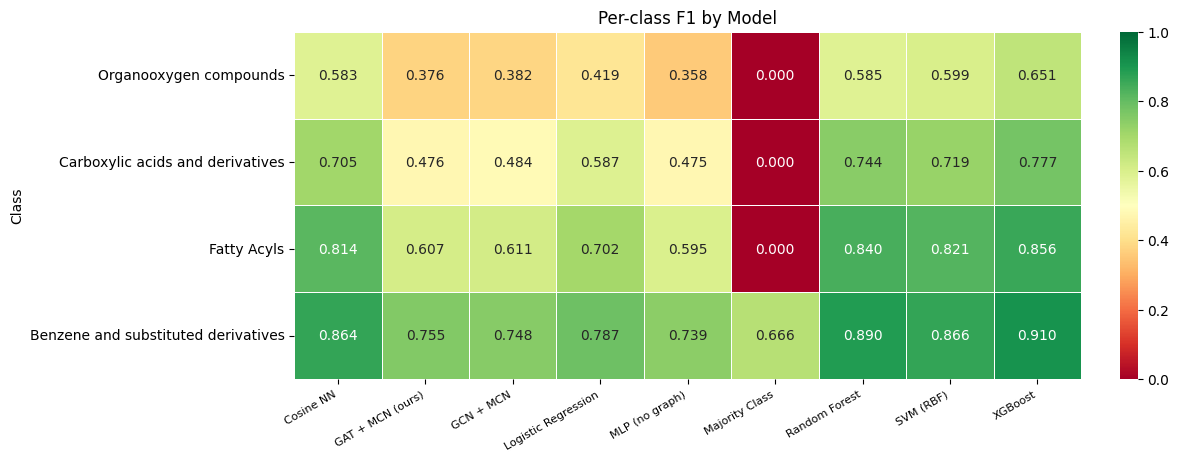

Saved: ablation_b_perclass_f1.csv, ablation_b_perclass_heatmap.png


In [15]:
class_names = list(le_cl.classes_)
perclass_rows = []
for name, m in ALL_RESULTS.items():
    pf1 = m['per_class_f1']
    for ci, cname in enumerate(class_names):
        perclass_rows.append({'Model': name, 'Class': cname,
                              'F1': round(float(pf1[ci]) if ci < len(pf1) else 0.0, 4)})

df_pc       = pd.DataFrame(perclass_rows)
df_pc_pivot = df_pc.pivot(index='Class', columns='Model', values='F1')
df_pc_pivot = df_pc_pivot.loc[df_pc_pivot.mean(axis=1).sort_values().index]

print('Per-class F1 (mean over seeds; hardest classes at top):')
print(df_pc_pivot.to_string())
df_pc_pivot.to_csv(os.path.join(RESULTS_DIR, 'ablation_b_perclass_f1.csv'))

fig, ax = plt.subplots(figsize=(max(10, len(ALL_RESULTS) * 1.3), 4.5), constrained_layout=True)
sns.heatmap(df_pc_pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.4, ax=ax)
ax.set_title('Per-class F1 by Model'); ax.set_xlabel(''); ax.set_ylabel('Class')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_b_perclass_heatmap.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Saved: ablation_b_perclass_f1.csv, ablation_b_perclass_heatmap.png')


## 15 Confusion Matrix (Best Model)

Uses the seed-0 prediction stored for the model with the highest mean macro-F1 (see
`y_true_example` / `y_pred_example` in `ALL_RESULTS`).

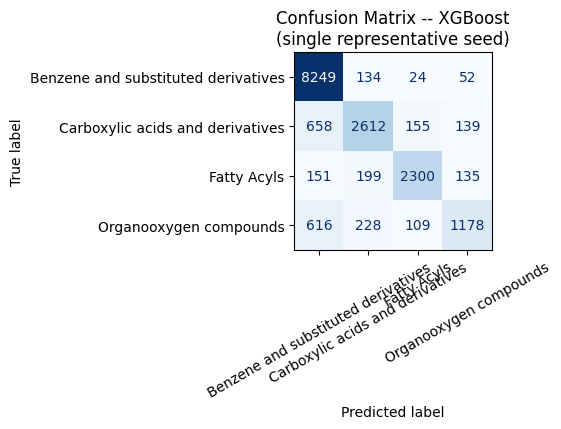

Best model: XGBoost
Saved: ablation_b_confusion_matrix.png


In [16]:
best_model = df_results.iloc[0]['Model']
bm = ALL_RESULTS[best_model]
cm = confusion_matrix(bm['y_true_example'], bm['y_pred_example'], labels=np.arange(N_CL))

fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
ax.set_title(f'Confusion Matrix -- {best_model}\n(single representative seed)')
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_b_confusion_matrix.png'), dpi=130, bbox_inches='tight')
plt.show()
print(f'Best model: {best_model}')
print('Saved: ablation_b_confusion_matrix.png')


## 16 Summary Visualisation

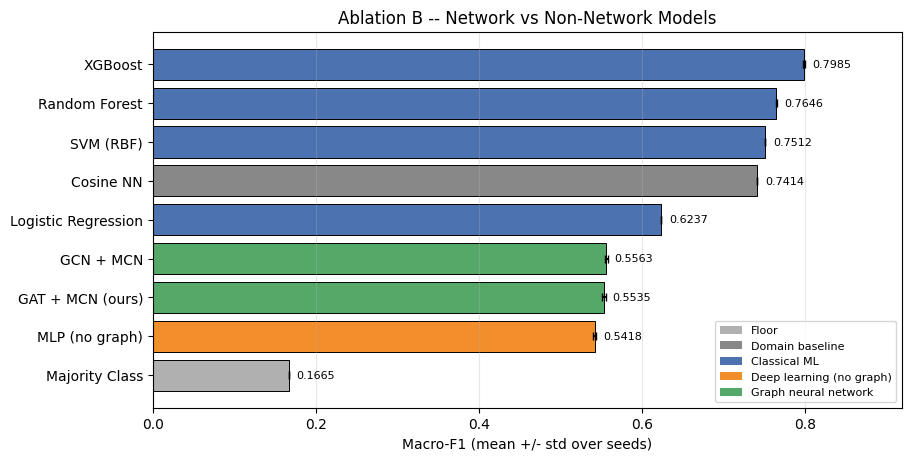

Saved: ablation_b_summary.png


In [17]:
model_order = df_results['Model'].tolist()
means = [ALL_RESULTS[n]['macro_f1_mean'] for n in model_order]
stds  = [ALL_RESULTS[n]['macro_f1_std']  for n in model_order]

def model_color(name):
    if name in ('GAT + MCN (ours)', 'GCN + MCN'): return '#55A868'
    if name == 'MLP (no graph)': return '#f28e2b'
    if name in ('Majority Class',): return '#B0B0B0'
    if name == 'Cosine NN': return '#888888'
    return '#4C72B0'

colors = [model_color(n) for n in model_order]

fig, ax = plt.subplots(figsize=(9, max(4.5, len(model_order) * 0.5)), constrained_layout=True)
bars = ax.barh(model_order[::-1], means[::-1], xerr=stds[::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.7, capsize=3)
for bar, v in zip(bars, means[::-1]):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Macro-F1 (mean +/- std over seeds)')
ax.set_title('Ablation B -- Network vs Non-Network Models')
ax.set_xlim(0, min(1.0, max(means) * 1.15))
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#B0B0B0', label='Floor'),
    Patch(facecolor='#888888', label='Domain baseline'),
    Patch(facecolor='#4C72B0', label='Classical ML'),
    Patch(facecolor='#f28e2b', label='Deep learning (no graph)'),
    Patch(facecolor='#55A868', label='Graph neural network'),
], loc='lower right', fontsize=8)

plt.savefig(os.path.join(RESULTS_DIR, 'ablation_b_summary.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Saved: ablation_b_summary.png')
